## Modbus IDS (unsupervised) — window Isolation Forest

Aggregates traffic into time windows (default **10 s**), extracts per-window features (counts, entropy, inter-arrival stats, function-code histogram), and trains an **Isolation Forest** on benign data. **Alerts** are **anomalous windows** (`feat["if_pred"] == -1`) with **`t_start` / `t_end`** in epoch seconds — inspect PCAP or CSV rows in those intervals manually.

**Code:** `ids_pipeline/window_if.py`

**Dependencies:** `pandas`, `numpy`, `scikit-learn`, `matplotlib`

In [1]:
%pip install -q pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "ids_pipeline" / "window_if.py").is_file():
            return p
    here = start.resolve()
    return here.parent if here.name == "notebooks" else here


ROOT = _find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for _k in list(sys.modules):
    if _k == "ids_pipeline" or _k.startswith("ids_pipeline."):
        del sys.modules[_k]

from ids_pipeline import (
    WindowIFConfig,
    apply_benign_quantile_threshold,
    fit_and_score,
    fit_train_score_eval,
    first_orchestrator_start_epoch,
    flagged_window_fraction,
    load_attack_intervals,
    load_clean_csv,
    resolve_label_ts_offset,
    smallest_quantile_recall_under_flag_cap,
    suggest_eval_ts_offset_sec,
    time_alignment_report,
    window_attack_overlap_labels,
    window_overlap_precision,
    window_overlap_recall,
)


def confusion_tpfp_fn_tn(y_true, y_pred) -> np.ndarray:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = int(cm[0, 0]), int(cm[0, 1]), int(cm[1, 0]), int(cm[1, 1])
    return np.array([[tp, fp], [fn, tn]])

### Paths and configuration

- **`WindowIFConfig`**: `window_sec`, `win_contamination`, `n_estimators`, optional **`benign_alert_quantile`**. **`include_src_context` / `include_dst_context`**: use per-window **`n_unique_src` / `n_unique_dst`** (distinct IPs only—no raw addresses). **`drop_src_identity=True`** drops both for privacy/ablation.
- **`EVAL_TS_OFFSET_SEC`**: `None` auto-aligns CSV timestamps to JSONL episode intervals.
- **`train_frac`**: optional time-based train split; **`fit_benign_only`**: use only windows outside JSONL attacks (single-file fallback path).
- **Train → eval**: fit on `train_data/benign.csv`; score `Full Data 4-20/fulldata2.csv`.

In [3]:
DATA_DIR = ROOT / "Full Data 4-20"
EVAL_CSV = DATA_DIR / "fulldata2.csv"
TRAIN_CSV = ROOT / "train_data" / "benign.csv"
JSONL_PATHS = [
    DATA_DIR / "ids_events_orch1.jsonl",
    DATA_DIR / "ids_events_orch2.jsonl",
    DATA_DIR / "ids_events_orch3.jsonl",
]

EVAL_TS_OFFSET_SEC = None
df_eval = load_clean_csv(EVAL_CSV)
EVAL_TS_OFFSET_SEC, attack_intervals = resolve_label_ts_offset(
    df_eval["ts"].values, JSONL_PATHS, EVAL_TS_OFFSET_SEC
)
print(f"Label offset: EVAL_TS_OFFSET_SEC={EVAL_TS_OFFSET_SEC}  (intervals: {len(attack_intervals)})")
print(time_alignment_report(df_eval["ts"].values, attack_intervals, offset_sec=EVAL_TS_OFFSET_SEC))

cfg = WindowIFConfig(
    window_sec=10.0,
    include_dst_context=True,
    drop_src_identity=True,
    win_contamination="auto",
    n_estimators=300,
    train_frac=None,
    fit_benign_only=False,
    benign_alert_quantile=0.045,
)

if TRAIN_CSV.is_file():
    df_train = load_clean_csv(TRAIN_CSV)
    print("Fit IF on:", TRAIN_CSV.name, len(df_train), "rows")
    print("Score windows on:", EVAL_CSV.name, len(df_eval), "rows")
    res = fit_train_score_eval(
        df_train,
        df_eval,
        cfg,
        attack_intervals=None,
        label_ts_offset_sec=0.0,
    )
else:
    print("Single-file mode:", EVAL_CSV.name, "(fit_benign_only)")
    cfg_mixed = WindowIFConfig(
        window_sec=cfg.window_sec,
        include_src_context=cfg.include_src_context,
        include_dst_context=cfg.include_dst_context,
        drop_src_identity=cfg.drop_src_identity,
        win_contamination=cfg.win_contamination,
        n_estimators=cfg.n_estimators,
        train_frac=0.7,
        fit_benign_only=True,
        benign_alert_quantile=cfg.benign_alert_quantile,
    )
    res = fit_and_score(
        df_eval,
        cfg_mixed,
        attack_intervals=attack_intervals,
        label_ts_offset_sec=float(EVAL_TS_OFFSET_SEC),
    )

df, feat = res.df, res.feat
print("t_cut:", res.t_cut, "| separate_eval_corpus:", res.separate_eval_corpus)
if res.benign_thresh_win is not None:
    print("Benign quantile: q =", cfg.benign_alert_quantile, "if_score <=", res.benign_thresh_win)

df.head()

Label offset: EVAL_TS_OFFSET_SEC=14160.0  (intervals: 68)
Time alignment (epoch seconds)
  CSV packets: n=479500 min=1776681948.036 max=1776689199.342
  JSONL episode union: n_intervals=68 min=1776696521.354 max=1776703717.205
  Packets inside any interval (ts + 14160): 35293 (7.360%)
Fit IF on: benign.csv 421704 rows
Score windows on: fulldata2.csv 479500 rows
t_cut: None | separate_eval_corpus: True
Benign quantile: q = 0.045 if_score <= -0.03323919818455502


,Time,Src IP,Dst IP,Trans_ID,Unit_ID,Func,Type,Data,ts,w
0,2026-04-20 10:45:48.036,10.30.0.22,10.30.0.5,1,0,3.0,Request,"startAddr: 0, quantity: 4",1.776682e+09,0
1,2026-04-20 10:45:48.037,10.30.0.5,10.30.0.22,1,0,3.0,Response,"byteCount: 8, registerVal: [141, 334, 281, 349]",1.776682e+09,0
2,2026-04-20 10:45:48.037,10.30.0.22,10.30.0.5,2,0,4.0,Request,"startAddr: 2, quantity: 5",1.776682e+09,0
3,2026-04-20 10:45:48.038,10.30.0.5,10.30.0.22,2,0,4.0,Response,"byteCount: 10, registerVal: [0, 0, 0, 340, 4500]",1.776682e+09,0
4,2026-04-20 10:45:49.857,10.30.0.32,10.30.0.5,1,0,2.0,Request,"startAddr: 0, quantity: 6",1.776682e+09,0


### Quick counts and anomalous windows

Use **`anom_windows`** (`t_start`, `t_end`) to scope manual packet review in **`df`**.

In [4]:
n_win = len(feat)
n_anom = int((feat["if_pred"] == -1).sum())
print(f"Windows: {n_win} | anomalous (if_pred=-1): {n_anom}")

anom_windows = feat.loc[feat["if_pred"] == -1, ["w", "t_start", "t_end", "if_score", "n_msgs"]].sort_values(
    "t_start"
)
print(f"Anomalous windows: {len(anom_windows)}")
anom_windows.head(40)

Windows: 726 | anomalous (if_pred=-1): 149
Anomalous windows: 149


,w,t_start,t_end,if_score,n_msgs
0,0,1.776682e+09,1.776682e+09,-0.206857,220
1,1,1.776682e+09,1.776682e+09,-0.086799,554
17,17,1.776682e+09,1.776682e+09,-0.138212,1304
18,18,1.776682e+09,1.776682e+09,-0.142111,842
19,19,1.776682e+09,1.776682e+09,-0.040219,588
23,23,1.776682e+09,1.776682e+09,-0.160761,1868
25,25,1.776682e+09,1.776682e+09,-0.170544,1640
33,33,1.776682e+09,1.776682e+09,-0.043150,597
34,34,1.776682e+09,1.776682e+09,-0.168241,823
35,35,1.776682e+09,1.776682e+09,-0.147657,1401


### Window IF score vs time

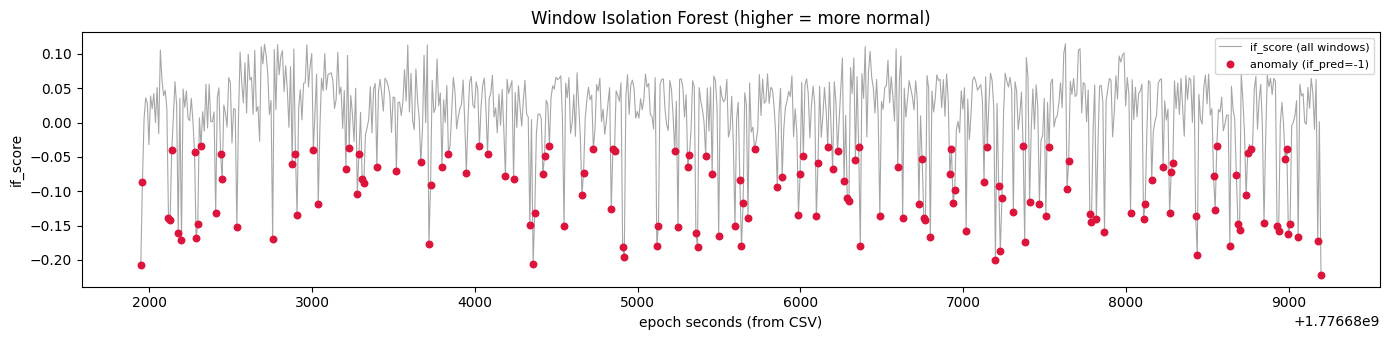

In [5]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(feat["t_start"], feat["if_score"], lw=0.8, color="0.65", label="if_score (all windows)")
mask = feat["if_pred"] == -1
if mask.any():
    ax.scatter(
        feat.loc[mask, "t_start"],
        feat.loc[mask, "if_score"],
        color="crimson",
        s=22,
        zorder=5,
        label="anomaly (if_pred=-1)",
    )
if res.t_cut is not None and not res.separate_eval_corpus:
    ax.axvline(res.t_cut, color="navy", ls="--", lw=1, label="train | test cut")
ax.set_title("Window Isolation Forest (higher = more normal)")
ax.set_xlabel("epoch seconds (from CSV)")
ax.set_ylabel("if_score")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

### Evaluation vs JSONL (window-level)

**Positive windows:** `[t_start, t_end]` plus **`EVAL_TS_OFFSET_SEC`** overlaps any JSONL episode interval.

**Predicted positive:** `if_pred == -1`.

In [6]:
attack_intervals = load_attack_intervals(JSONL_PATHS)
print(f"Loaded {len(attack_intervals)} attack intervals")
print(time_alignment_report(df["ts"].values, attack_intervals, offset_sec=0.0))
fo = first_orchestrator_start_epoch(JSONL_PATHS)
if fo is not None:
    print("First orchestrator_start minus CSV ts min (s):", fo - float(df["ts"].min()))

if EVAL_TS_OFFSET_SEC is None:
    off, nh = suggest_eval_ts_offset_sec(df["ts"].values, attack_intervals)
    EVAL_TS_OFFSET_SEC = float(off)
    print(f"AUTO EVAL_TS_OFFSET_SEC = {EVAL_TS_OFFSET_SEC} (packets in any interval: {nh})")
else:
    print(f"Using EVAL_TS_OFFSET_SEC = {EVAL_TS_OFFSET_SEC}")
print(time_alignment_report(df["ts"].values, attack_intervals, offset_sec=float(EVAL_TS_OFFSET_SEC)))

if attack_intervals:
    off = float(EVAL_TS_OFFSET_SEC)
    y_true = window_attack_overlap_labels(feat, attack_intervals, offset_sec=off)
    y_pred = (feat["if_pred"].values == -1).astype(np.int8)
    print("\n=== Window IF vs JSONL interval overlap ===")
    print("confusion [[TP, FP], [FN, TN]]:", confusion_tpfp_fn_tn(y_true, y_pred).tolist())
    print(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["win_ok", "win_attack_overlap"],
            digits=3,
            zero_division=0,
        )
    )
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )
    print(f"Binary P/R/F1 (anomalous window=1): P={p:.4f} R={r:.4f} F1={f1:.4f}")
else:
    print("No JSONL intervals.")

Loaded 68 attack intervals
Time alignment (epoch seconds)
  CSV packets: n=479500 min=1776681948.036 max=1776689199.342
  JSONL episode union: n_intervals=68 min=1776696521.354 max=1776703717.205
  Packets inside any interval (ts + 0): 0 (0.000%)
First orchestrator_start minus CSV ts min (s): 14414.98172903061
Using EVAL_TS_OFFSET_SEC = 14160.0
Time alignment (epoch seconds)
  CSV packets: n=479500 min=1776681948.036 max=1776689199.342
  JSONL episode union: n_intervals=68 min=1776696521.354 max=1776703717.205
  Packets inside any interval (ts + 14160): 35293 (7.360%)

=== Window IF vs JSONL interval overlap ===
confusion [[TP, FP], [FN, TN]]: [[32, 117], [66, 511]]
                    precision    recall  f1-score   support

            win_ok      0.886     0.814     0.848       628
win_attack_overlap      0.215     0.327     0.259        98

          accuracy                          0.748       726
         macro avg      0.550     0.570     0.554       726
      weighted avg     

### Recall calibration with a flag-rate cap (no refit)

`train_if_scores` are IF scores on **fit** windows only. We sweep **`benign_alert_quantile` `q`** and set **`feat["if_pred"]`** from `if_score <= quantile(train_if_scores, q)`.

**Joint target:** pick the **smallest** `q` such that **overlap recall** ≥ **`TARGET_RECALL`** and at most **`MAX_FLAGGED_FRACTION`** of windows are flagged. That avoids chasing recall alone, which loosens `q` and tends to **flag almost every window**. If the joint target is **infeasible** (model / threshold grid cannot separate attack windows from the rest under the cap), we fall back to **best recall under the flag cap** (`q_met` is `None` in the helper).

Re-run **Evaluation** above if you need the default matrix; this cell **overwrites** `feat["if_pred"]` for the chosen `q`.

In [11]:
TARGET_RECALL = 0.6
MAX_FLAGGED_FRACTION = 0.30

if not attack_intervals:
    print("No attack_intervals loaded.")
elif getattr(res, "train_if_scores", None) is None:
    print("res.train_if_scores missing — use fit_train_score_eval with benign quantile or update ids_pipeline.")
else:
    off = float(EVAL_TS_OFFSET_SEC)
    y_ov = window_attack_overlap_labels(feat, attack_intervals, offset_sec=off)
    q_met, q_applied, _, _, _, _ = smallest_quantile_recall_under_flag_cap(
        feat,
        res.train_if_scores,
        y_ov,
        target_recall=TARGET_RECALL,
        max_flagged_fraction=MAX_FLAGGED_FRACTION,
        q_min=0.02,
        q_max=0.92,
        n_steps=91,
    )
    feat, thr = apply_benign_quantile_threshold(feat, res.train_if_scores, q_applied)
    y_pred = (feat["if_pred"].values == -1).astype(np.int8)
    r_now = window_overlap_recall(y_ov, feat["if_pred"].values)
    p_now = window_overlap_precision(y_ov, feat["if_pred"].values)
    ff_now = flagged_window_fraction(feat["if_pred"].values)
    joint = q_met is not None
    print(
        f"Joint recall≥{TARGET_RECALL} & flagged≤{MAX_FLAGGED_FRACTION}: "
        f"{'yes' if joint else 'no (fallback: max recall under flag cap)'}\n"
        f"q_applied={q_applied:.4f}  score threshold={thr:.6f}\n"
        f"overlap recall={r_now:.4f}  precision={p_now:.4f}  flagged window fraction={ff_now:.4f}"
    )
    print("confusion [[TP, FP], [FN, TN]]:", confusion_tpfp_fn_tn(y_ov, y_pred).tolist())
    print(
        classification_report(
            y_ov,
            y_pred,
            labels=[0, 1],
            target_names=["win_ok", "win_attack_overlap"],
            digits=3,
            zero_division=0,
        )
    )

Chosen q=0.1900  score threshold=0.027135  overlap recall=0.6122  (target was 0.6)
confusion [[TP, FP], [FN, TN]]: [[60, 311], [38, 317]]
                    precision    recall  f1-score   support

            win_ok      0.893     0.505     0.645       628
win_attack_overlap      0.162     0.612     0.256        98

          accuracy                          0.519       726
         macro avg      0.527     0.559     0.450       726
      weighted avg      0.794     0.519     0.592       726

